In [1]:
import sys
import os

os.chdir('../')
os.getcwd()

'c:\\Users\\luisa\\Documents\\LX1_GitHub_Repos\\ai_cheme_examples'

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import hdbscan


from sklearn.preprocessing import MinMaxScaler
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split

from scipy import stats
from scipy import interpolate
from scipy.interpolate import CubicSpline

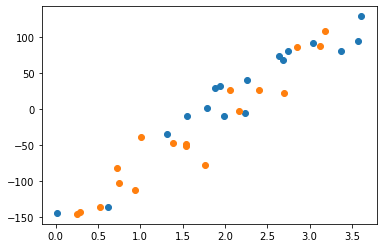

In [3]:
X, y = make_regression(n_samples=35, n_features=1, noise=30, random_state=21)

X  = X + 2

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=13)

plt.scatter(X_train, y_train)
plt.scatter(X_test, y_test)


In [4]:
train_set = np.array([X_train[:, 0], y_train]).reshape(2, -1).transpose()

train_set = train_set[train_set[:, 0].argsort()]

X_train_sorted = train_set[:, 0]
y_train_sorted = train_set[:, 1]

train_set

array([[ 1.58183857e-02, -1.44958407e+02],
       [ 6.16043131e-01, -1.36540507e+02],
       [ 1.31077173e+00, -3.38151837e+01],
       [ 1.55188440e+00, -9.05754930e+00],
       [ 1.79413562e+00,  1.31564642e+00],
       [ 1.88880395e+00,  2.88849517e+01],
       [ 1.94803575e+00,  3.26663258e+01],
       [ 1.98737405e+00, -9.73069434e+00],
       [ 2.23180296e+00, -4.88819329e+00],
       [ 2.25722913e+00,  4.12066473e+01],
       [ 2.64415927e+00,  7.35230154e+01],
       [ 2.69192371e+00,  6.87390935e+01],
       [ 2.74538768e+00,  8.03885123e+01],
       [ 3.04179680e+00,  9.24085857e+01],
       [ 3.37368850e+00,  8.13526174e+01],
       [ 3.56788218e+00,  9.53473806e+01],
       [ 3.61099198e+00,  1.29279918e+02]])

In [5]:
f0 = interpolate.interp1d(X_train_sorted, y_train_sorted)
f1 = CubicSpline(X_train_sorted, y_train_sorted)

In [6]:
y_predicted0 = f0(X_test).reshape(-1, )
y_predicted1 = f1(X_test).reshape(-1, )

y_predicted = []

for y in [y_predicted0, y_predicted1]:
    predicted_set = np.array([X_test.reshape(-1, ), y]).reshape(2, -1).transpose()
    predicted_set = predicted_set[predicted_set[:, 0].argsort()]
    X_test_sorted = predicted_set[:, 0]
    y = predicted_set[:, 1]

    y_predicted.append(y)

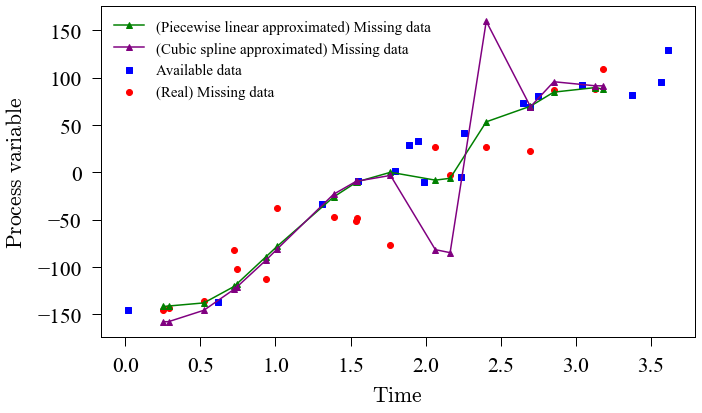

In [13]:
fig = plt.figure(figsize=(10, 6))
axs0 = fig.add_subplot(1, 1, 1)

axs0.scatter(X_train, y_train, color = 'b', label = 'Available data', marker = 's')
axs0.scatter(X_test, y_test, color = 'r', label = '(Real) Missing data')
axs0.plot(X_test_sorted, y_predicted[0], color = 'g', ls = '-', marker = '^', label = '(Piecewise linear approximated) Missing data')
axs0.plot(X_test_sorted, y_predicted[1], color = 'purple', ls = '-', marker = '^', label = '(Cubic spline approximated) Missing data')

axs0.set_xlabel(r'$ \rm Time$', labelpad = 10, fontsize='x-large')
axs0.set_ylabel(r'$ \rm Process\ variable$', labelpad = 10, fontsize='x-large')

axs0.tick_params(direction='out',
                    pad=10,
                    length=9,
                    width=1,
                    labelsize='x-large')

axs0.tick_params(which='minor',
                    direction='out',
                    pad=10,
                    length=5,
                    width=1,
                    labelsize='x-large')

for ax in ['top', 'bottom', 'left', 'right']:
    axs0.spines[ax].set_linewidth(1)


plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman"
                                ] + plt.rcParams["font.serif"]
plt.rcParams['font.size']=15
plt.rcParams['axes.linewidth'] = 1 

plt.legend(frameon = False)
plt.tight_layout()

plt.savefig('figures/example-2-2.png', dpi = 300)

plt.show()